# UrbanShift Churn Model — Multicollinearity Assessment

This notebook assesses multicollinearity in `customer_churn_model_table.csv`.

It performs:

1. Model-ready table loading
2. Feature/target separation
3. Numeric feature correlation analysis
4. High-correlation pair detection
5. Variance Inflation Factor (VIF) analysis
6. Business-friendly feature review recommendations
7. Output artifact generation (for example, correlation heatmap image)

The goal is not to remove every correlated feature automatically. The goal is to identify features that may distort model interpretation, especially feature importance in SageMaker Canvas.

In [25]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## 1. Configuration

Update `DATA_PATH` if your CSV is stored somewhere else.

Expected input file:

```text
customer_churn_model_table.csv
```


In [26]:
DATA_PATH = Path('outputs/customer_churn_model_table.csv')
TARGET_COL = 'at_risk'
ID_COLS = ['customer_id', 'snapshot_date']

CORR_THRESHOLD = 0.80
HIGH_CORR_THRESHOLD = 0.90
VIF_MODERATE_THRESHOLD = 5
VIF_HIGH_THRESHOLD = 10

OUTPUT_DIR = Path('multicollinearity_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATH


WindowsPath('outputs/customer_churn_model_table.csv')

## 2. Load Model-Ready Data

In [27]:
model_df = pd.read_csv(DATA_PATH)

print(f'Rows: {model_df.shape[0]:,}')
print(f'Columns: {model_df.shape[1]:,}')
display(model_df.head())


Rows: 714
Columns: 22


,customer_id,snapshot_date,customer_size,city,industry,industry_revenue_share,industry_relative_revenue_strength,payment_terms_days,customer_tenure_days,avg_revenue_per_delivery_lookback_60d,relative_volume_strength,volume_growth_lookback,relative_volume_growth_lookback,failed_delivery_rate_lookback_60d,return_rate_lookback_60d,avg_delivery_time_lookback_60d,incident_rate_lookback_60d,complaint_rate_lookback_60d,late_delivery_rate_lookback_60d,damaged_parcel_rate_lookback_60d,lost_parcel_rate_lookback_60d,at_risk
0,CUST1000,2024-11-30,Mid-size Retailer,London,Beauty,0.1235,NaN,60,901,5.9485,2.4842,-0.0813,-0.1467,0.0424,0.0169,72.7246,0.1695,0.0381,0.0169,0.0466,0.0127,0
1,CUST1001,2024-11-30,Mid-size Retailer,London,Books,0.0890,NaN,30,199,6.0662,3.8842,-0.0161,-0.0815,0.0379,0.0271,70.0515,0.1762,0.0298,0.0325,0.0407,0.0163,0
2,CUST1002,2024-11-30,Small Retailer,Bristol,Fashion,0.3638,NaN,30,759,4.6576,0.5368,-0.0385,-0.1039,0.0784,0.0588,65.0392,0.2941,0.0392,0.0980,0.0588,0.0588,0
3,CUST1003,2024-11-30,Small Retailer,Leeds,Beauty,0.1235,NaN,60,155,4.6540,0.3684,-0.1579,-0.2233,0.0286,0.0571,66.5143,0.2000,0.0571,0.0571,0.0286,0.0000,0
4,CUST1004,2024-11-30,Small Retailer,Manchester,Electronics,0.1282,NaN,30,886,4.6270,1.2211,-0.0667,-0.1321,0.0517,0.0345,66.0259,0.2845,0.0345,0.0690,0.0690,0.0259,0


## 3. Separate Features from ID and Target Columns

We exclude identifiers and the target variable from multicollinearity checks.

Identifiers such as `customer_id` and `snapshot_date` are not predictive features for the Canvas model.


In [28]:
available_id_cols = [col for col in ID_COLS if col in model_df.columns]

if TARGET_COL not in model_df.columns:
    raise ValueError(f'Target column {TARGET_COL!r} was not found in the dataset.')

feature_df = model_df.drop(columns=available_id_cols + [TARGET_COL], errors='ignore')

numeric_feature_df = feature_df.select_dtypes(include=[np.number]).copy()
categorical_feature_df = feature_df.select_dtypes(exclude=[np.number]).copy()

print('Identifier columns excluded:', available_id_cols)
print('Target column excluded:', TARGET_COL)
print(f'Numeric features assessed: {numeric_feature_df.shape[1]}')
print(f'Categorical features not assessed by correlation/VIF: {categorical_feature_df.shape[1]}')

if categorical_feature_df.shape[1] > 0:
    print('Categorical columns:')
    print(list(categorical_feature_df.columns))


Identifier columns excluded: ['customer_id', 'snapshot_date']
Target column excluded: at_risk
Numeric features assessed: 16
Categorical features not assessed by correlation/VIF: 3
Categorical columns:
['customer_size', 'city', 'industry']


## 4. Basic Numeric Feature Health Check

Before calculating VIF, handle values that can break multicollinearity analysis:

- all-null features
- constant features
- infinite values (converted to missing)

Features are excluded only when they are all-null or constant after cleaning. Remaining missing numeric values are median-imputed for analysis only.

These should be reviewed separately because they may also cause modelling problems.

In [29]:
numeric_clean = numeric_feature_df.replace([np.inf, -np.inf], np.nan)

feature_health = pd.DataFrame({
    'missing_count': numeric_clean.isna().sum(),
    'missing_pct': numeric_clean.isna().mean(),
    'unique_values': numeric_clean.nunique(dropna=True),
    'variance': numeric_clean.var(numeric_only=True)
}).sort_values(['unique_values', 'missing_pct'])

display(feature_health)

problem_features = feature_health[
    (feature_health['unique_values'] <= 1) |
    (feature_health['missing_pct'] == 1)
].index.tolist()

print('Features excluded from correlation/VIF due to being constant or all-null:')
print(problem_features)

numeric_analysis_df = numeric_clean.drop(columns=problem_features, errors='ignore')

# Impute remaining missing numeric values using median for analysis only.
# This does not change the modelling dataset.
numeric_analysis_df = numeric_analysis_df.fillna(numeric_analysis_df.median(numeric_only=True))

print(f'Numeric features retained for multicollinearity analysis: {numeric_analysis_df.shape[1]}')


,missing_count,missing_pct,unique_values,variance
payment_terms_days,0,0.0000,4,140.3384
industry_relative_revenue_strength,120,0.1681,35,0.0011
industry_revenue_share,0,0.0000,42,0.0169
return_rate_lookback_60d,0,0.0000,320,0.0005
lost_parcel_rate_lookback_60d,0,0.0000,324,0.0004
complaint_rate_lookback_60d,0,0.0000,369,0.0007
damaged_parcel_rate_lookback_60d,0,0.0000,371,0.0007
failed_delivery_rate_lookback_60d,0,0.0000,378,0.0007
late_delivery_rate_lookback_60d,0,0.0000,379,0.0007
volume_growth_lookback,0,0.0000,451,0.0471


Features excluded from correlation/VIF due to being constant or all-null:
[]
Numeric features retained for multicollinearity analysis: 16


## 5. Correlation Matrix

Correlation identifies pairs of numeric features that move together.

Useful thresholds:

| Absolute correlation | Interpretation |
|---:|---|
| 0.80+ | Strong relationship; review needed |
| 0.90+ | Very strong relationship; likely redundancy |

For this project, correlation is most important because highly correlated features can make feature importance harder to explain to stakeholders.


In [ ]:
corr_matrix = numeric_analysis_df.corr()
display(corr_matrix)

,industry_revenue_share,industry_relative_revenue_strength,payment_terms_days,customer_tenure_days,avg_revenue_per_delivery_lookback_60d,relative_volume_strength,volume_growth_lookback,relative_volume_growth_lookback,failed_delivery_rate_lookback_60d,return_rate_lookback_60d,avg_delivery_time_lookback_60d,incident_rate_lookback_60d,complaint_rate_lookback_60d,late_delivery_rate_lookback_60d,damaged_parcel_rate_lookback_60d,lost_parcel_rate_lookback_60d
industry_revenue_share,1.0000,0.6759,-0.0194,0.0594,-0.0220,0.2086,0.0432,0.0631,-0.0052,-0.0397,-0.0148,0.0499,-0.0294,0.0933,-0.0203,0.0007
industry_relative_revenue_strength,0.6759,1.0000,-0.1010,0.0018,0.0216,0.1556,0.0146,0.0706,-0.0182,-0.0250,-0.0050,0.0716,0.0096,0.0504,-0.0041,0.0635
payment_terms_days,-0.0194,-0.1010,1.0000,0.0300,-0.0134,0.1629,-0.0546,-0.0888,-0.0257,0.0474,-0.1130,-0.0587,-0.0260,-0.0861,-0.0172,-0.0733
customer_tenure_days,0.0594,0.0018,0.0300,1.0000,-0.0294,0.0143,-0.0247,-0.0749,0.0200,-0.0137,0.0264,0.0290,-0.0621,0.0355,-0.0100,0.0984
avg_revenue_per_delivery_lookback_60d,-0.0220,0.0216,-0.0134,-0.0294,1.0000,-0.0277,-0.0177,-0.0319,0.0561,-0.0167,0.0199,0.0542,0.0592,-0.0138,-0.0000,-0.0023
relative_volume_strength,0.2086,0.1556,0.1629,0.0143,-0.0277,1.0000,0.0588,0.0927,0.0435,-0.0055,0.0123,0.0541,0.0275,0.0032,0.0048,0.0175
volume_growth_lookback,0.0432,0.0146,-0.0546,-0.0247,-0.0177,0.0588,1.0000,0.6214,0.0086,0.0176,0.0181,-0.0262,0.0103,-0.0405,0.0424,-0.0345
relative_volume_growth_lookback,0.0631,0.0706,-0.0888,-0.0749,-0.0319,0.0927,0.6214,1.0000,0.0316,-0.0088,0.0269,-0.0051,0.0227,0.0001,0.0182,-0.0229
failed_delivery_rate_lookback_60d,-0.0052,-0.0182,-0.0257,0.0200,0.0561,0.0435,0.0086,0.0316,1.0000,0.0182,-0.0490,0.4225,0.1226,0.2059,0.1458,0.2199
return_rate_lookback_60d,-0.0397,-0.0250,0.0474,-0.0137,-0.0167,-0.0055,0.0176,-0.0088,0.0182,1.0000,-0.0258,0.2988,0.1258,0.1524,0.1214,-0.0131


## 6. Correlation Heatmap

This is a quick visual scan. Darker blocks indicate groups of features that may be measuring similar underlying behaviour.


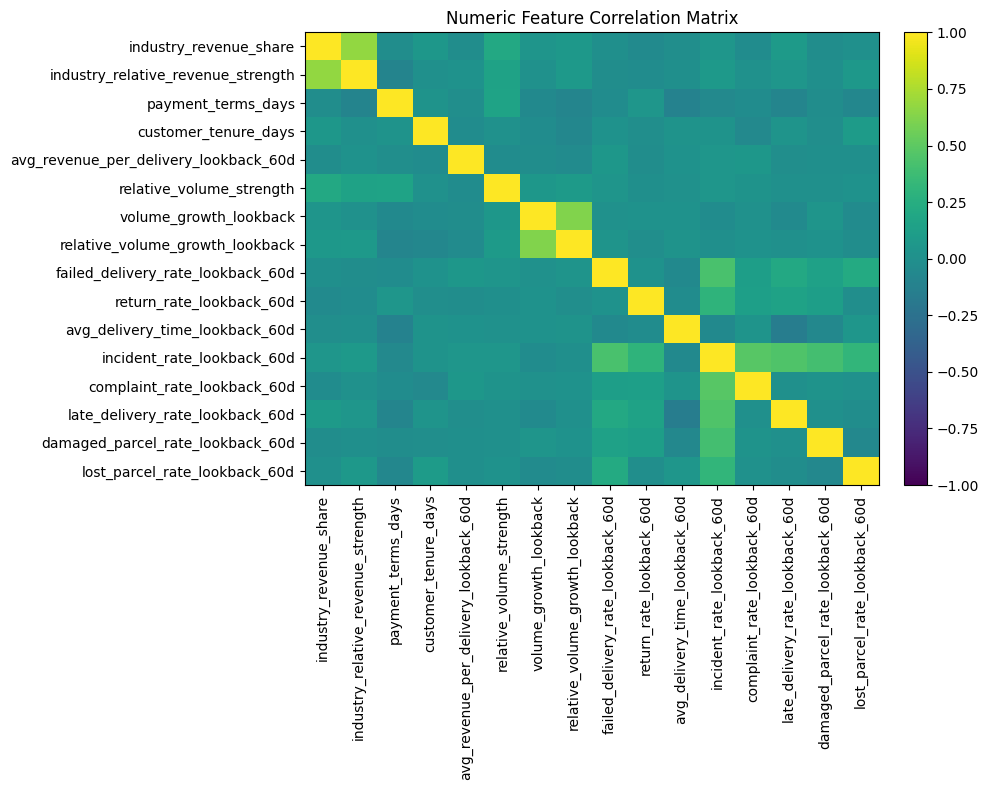

In [31]:
if corr_matrix.shape[0] > 1:
    fig, ax = plt.subplots(figsize=(max(10, corr_matrix.shape[0] * 0.45), max(8, corr_matrix.shape[0] * 0.45)))
    im = ax.imshow(corr_matrix.values, aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_xticklabels(corr_matrix.columns, rotation=90)
    ax.set_yticklabels(corr_matrix.index)
    ax.set_title('Numeric Feature Correlation Matrix')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('Not enough numeric features to produce a correlation heatmap.')


## 7. Identify Highly Correlated Feature Pairs

This table is the most useful output for the ML report.

Review each pair and decide whether to:

- keep both because they represent different business concepts
- remove one because they are redundant
- keep one for modelling but mention the limitation when interpreting feature importance


In [ ]:
def get_high_corr_pairs(corr: pd.DataFrame, threshold: float = 0.8) -> pd.DataFrame:
    pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            val = corr.iloc[i, j]
            if pd.notna(val) and abs(val) >= threshold:
                pairs.append({
                    'feature_a': cols[i],
                    'feature_b': cols[j],
                    'correlation': val,
                    'abs_correlation': abs(val),
                    'severity': 'very_high' if abs(val) >= HIGH_CORR_THRESHOLD else 'high'
                })
    if not pairs:
        return pd.DataFrame(columns=['feature_a', 'feature_b', 'correlation', 'abs_correlation', 'severity'])
    return pd.DataFrame(pairs).sort_values('abs_correlation', ascending=False)

high_corr_pairs = get_high_corr_pairs(corr_matrix, CORR_THRESHOLD)

display(high_corr_pairs)

,feature_a,feature_b,correlation,abs_correlation,severity


## 8. Variance Inflation Factor (VIF)

VIF measures how well each numeric feature can be explained by the other numeric features.

Rules of thumb:

| VIF | Interpretation |
|---:|---|
| < 5 | Usually acceptable |
| 5–10 | Moderate multicollinearity |
| > 10 | High multicollinearity |

VIF is most important for linear models. Canvas may use tree-based models, but VIF is still helpful for understanding whether feature importance may be unstable.


In [ ]:
def calculate_vif(df: pd.DataFrame) -> pd.DataFrame:
    # VIF_j = 1 / (1 - R2_j), where R2_j comes from regressing feature j on all other features.
    # This implementation avoids requiring statsmodels.
    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import StandardScaler

    if df.shape[1] < 2:
        return pd.DataFrame(columns=['feature', 'vif', 'r_squared_explained_by_other_features'])

    X_scaled = pd.DataFrame(
        StandardScaler().fit_transform(df),
        columns=df.columns,
        index=df.index
    )

    rows = []
    for feature in X_scaled.columns:
        y = X_scaled[feature].values
        X_other = X_scaled.drop(columns=[feature]).values

        model = LinearRegression()
        model.fit(X_other, y)
        r2 = model.score(X_other, y)

        vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)
        rows.append({'feature': feature, 'vif': vif, 'r_squared_explained_by_other_features': r2})

    return pd.DataFrame(rows).sort_values('vif', ascending=False)

vif_df = calculate_vif(numeric_analysis_df)

vif_df['vif_level'] = np.select(
    [vif_df['vif'] > VIF_HIGH_THRESHOLD, vif_df['vif'] >= VIF_MODERATE_THRESHOLD],
    ['high', 'moderate'],
    default='low'
)

display(vif_df)

,feature,vif,r_squared_explained_by_other_features,vif_level
11,incident_rate_lookback_60d,3.9742,0.7484,low
0,industry_revenue_share,1.9324,0.4825,low
1,industry_relative_revenue_strength,1.9087,0.4761,low
12,complaint_rate_lookback_60d,1.7708,0.4353,low
13,late_delivery_rate_lookback_60d,1.7643,0.4332,low
7,relative_volume_growth_lookback,1.6710,0.4016,low
6,volume_growth_lookback,1.6475,0.3930,low
14,damaged_parcel_rate_lookback_60d,1.6035,0.3764,low
15,lost_parcel_rate_lookback_60d,1.4807,0.3246,low
8,failed_delivery_rate_lookback_60d,1.2713,0.2134,low


## 9. Suggested Review Actions

This section creates an initial recommendation table.

The recommendations are deliberately conservative. Do not blindly drop features purely because a statistic is high. For this project, business meaning matters.


In [ ]:
def classify_feature_name(feature: str) -> str:
    name = feature.lower()
    if 'revenue' in name:
        return 'revenue'
    if 'deliver' in name or 'volume' in name:
        return 'volume'
    if 'incident' in name or 'complaint' in name or 'late' in name or 'lost' in name or 'damaged' in name:
        return 'incident'
    if 'fail' in name or 'return' in name or 'status' in name or 'time' in name:
        return 'service_quality'
    if 'tenure' in name or 'payment' in name:
        return 'customer_profile'
    return 'other'

review_rows = []
for _, row in high_corr_pairs.iterrows():
    a = row['feature_a']
    b = row['feature_b']
    group_a = classify_feature_name(a)
    group_b = classify_feature_name(b)

    if group_a == group_b:
        action = 'Review for possible removal of one feature'
        reason = 'Both features appear to describe the same business concept.'
    else:
        action = 'Likely keep both, but caveat interpretation'
        reason = 'Features are correlated but may represent different business concepts.'

    review_rows.append({
        'feature_a': a,
        'feature_b': b,
        'correlation': row['correlation'],
        'severity': row['severity'],
        'feature_a_group': group_a,
        'feature_b_group': group_b,
        'suggested_action': action,
        'reason': reason
    })

review_df = pd.DataFrame(review_rows)

display(review_df)

""


## 10. Feature Selection Notes Template

Use this table in your ML documentation after reviewing the outputs above.

Example language:

> Highly correlated features were reviewed before model training to reduce redundancy and improve interpretability. Where two features measured the same business concept, one was removed or deprioritised. Where correlated features represented different business concepts, both were retained and the limitation was documented.


In [ ]:
feature_selection_notes = pd.DataFrame(columns=[
    'feature_a',
    'feature_b',
    'correlation_or_vif',
    'decision',
    'business_rationale'
])

if not review_df.empty:
    feature_selection_notes = review_df[[
        'feature_a', 'feature_b', 'correlation', 'suggested_action', 'reason'
    ]].rename(columns={
        'correlation': 'correlation_or_vif',
        'suggested_action': 'decision',
        'reason': 'business_rationale'
    })

display(feature_selection_notes)

,feature_a,feature_b,correlation_or_vif,decision,business_rationale


## 11. Final Summary

Run this cell after the full notebook to get a concise summary for your report.


In [ ]:
n_high_pairs = len(high_corr_pairs)
n_very_high_pairs = int((high_corr_pairs['abs_correlation'] >= HIGH_CORR_THRESHOLD).sum()) if not high_corr_pairs.empty else 0
n_high_vif = int((vif_df['vif'] > VIF_HIGH_THRESHOLD).sum()) if not vif_df.empty else 0
n_moderate_vif = int(((vif_df['vif'] >= VIF_MODERATE_THRESHOLD) & (vif_df['vif'] <= VIF_HIGH_THRESHOLD)).sum()) if not vif_df.empty else 0

summary = f"""
Multicollinearity Summary
-------------------------
Numeric features assessed: {numeric_analysis_df.shape[1]}
High correlation pairs, |corr| >= {CORR_THRESHOLD}: {n_high_pairs}
Very high correlation pairs, |corr| >= {HIGH_CORR_THRESHOLD}: {n_very_high_pairs}
Features with moderate VIF, {VIF_MODERATE_THRESHOLD} <= VIF <= {VIF_HIGH_THRESHOLD}: {n_moderate_vif}
Features with high VIF, VIF > {VIF_HIGH_THRESHOLD}: {n_high_vif}

Recommended next step:
Review the high-correlation pair table and VIF table. Remove only features that are both statistically redundant and business-redundant. Keep correlated features where they explain different commercial behaviours, but mention the limitation when interpreting Canvas feature importance.
"""
print(summary)



Multicollinearity Summary
-------------------------
Numeric features assessed: 16
High correlation pairs, |corr| >= 0.8: 0
Very high correlation pairs, |corr| >= 0.9: 0
Features with moderate VIF, 5 <= VIF <= 10: 0
Features with high VIF, VIF > 10: 0

Recommended next step:
Review the high-correlation pair table and VIF table. Remove only features that are both statistically redundant and business-redundant. Keep correlated features where they explain different commercial behaviours, but mention the limitation when interpreting Canvas feature importance.

